## Placement Tier Predictor

Dataset loaded successfully.

PROJECT EVALUATION REPORT
Accuracy Score:    0.6900
F1 Score (Weight): 0.6938
R-squared (R2):    0.5801
RMSE (Error):      ₹3.06 LPA
--------------------------------------------------
SIMULATION RESULT:
Profile: CGPA 9.2, CSE Core, 2 Internships
Predicted Placement Tier: Super Dream


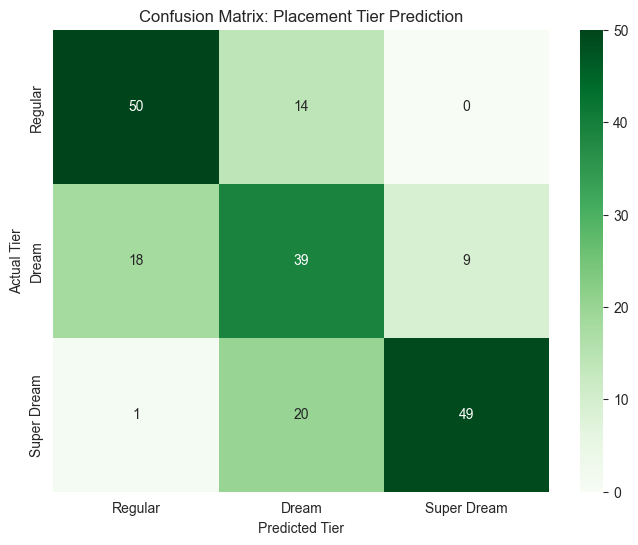

In [4]:
"""
AIML Capstone Project: Placement Tier Predictor
Description: This system analyzes student profiles to categorize them into
placement tiers. It utilizes data cleaning, feature engineering, and
Random Forest Classification.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# --- STEP 1: DATA LOADING ---
try:
    df = pd.read_csv("Placement_Data.csv")
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: Placement_Data.csv not found. Please run the data generation script first.")

# --- STEP 2: DATA CLEANING & PREPROCESSING ---
def clean_and_convert(df, column, unit_to_remove):
    """Strips units (like %) and converts column to numeric, handling nulls."""
    df[column] = df[column].astype(str).str.replace(unit_to_remove, '', regex=False).str.strip().replace('null', np.nan)
    return df

# Cleaning 'aptitude_score'
df = clean_and_convert(df, 'aptitude_score', '%')
df['aptitude_score'] = pd.to_numeric(df['aptitude_score'], errors='coerce')

# Handling missing values using median imputation to maintain data distribution
df['aptitude_score'] = df['aptitude_score'].fillna(df['aptitude_score'].median())
df['cgpa'] = df['cgpa'].fillna(df['cgpa'].median())

# --- STEP 3: FEATURE ENGINEERING ---
df['branch'] = df['student_id'].apply(lambda x: x.split(' ')[1] if len(x.split(' ')) > 1 else 'Unknown')
df.drop('student_id', axis=1, inplace=True)

# Mapping ordinal categorical data (Internships) to numeric values
internship_map = {'None': 0, 'First Internship': 1, 'Second Internship': 2, 'Third & Above': 3}
df['internships'] = df['internships'].map(internship_map)

# Calculating student seniority based on joining year
current_year = 2026
df['seniority_years'] = current_year - df['year_of_joining']
df.drop('year_of_joining', axis=1, inplace=True)

# --- STEP 4: TARGET TRANSFORMATION ---
df['placement_tier'] = pd.qcut(df['package_lpa'], q=3, labels=['Regular', 'Dream', 'Super Dream'])
y_regression = df['package_lpa'] # Saved for regression context later

# --- STEP 5: ENCODING & SCALING ---
categorical_cols = ['branch']
numerical_cols = ['cgpa', 'coding_score', 'aptitude_score', 'projects', 'internships', 'backlogs', 'seniority_years']

# One-Hot Encoding for categorical 'branch' column
df_encoded = pd.get_dummies(df.drop('package_lpa', axis=1), columns=categorical_cols, drop_first=True)

X = df_encoded.drop('placement_tier', axis=1)
y_classification = df_encoded['placement_tier']

# Standardizing numerical features to ensure equal weightage in the model
scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

# --- STEP 6: MODEL TRAINING ---
X_train, X_test, y_train, y_test = train_test_split(X, y_classification, test_size=0.2, random_state=42)

# Utilizing Random Forest for its robustness and ability to handle non-linear relationships
clf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, max_depth=15)
clf_model.fit(X_train, y_train)
y_pred_clf = clf_model.predict(X_test)

# --- STEP 7: REGRESSION CONTEXT ---
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X, y_regression, test_size=0.2, random_state=42)
reg_model_ctx = RandomForestClassifier(n_estimators=100, random_state=42)
reg_model_ctx.fit(X_reg_train, y_reg_train.astype(int))
y_pred_reg = reg_model_ctx.predict(X_reg_test)

rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_reg))
r2 = r2_score(y_reg_test, y_pred_reg)

# --- STEP 8: INFERENCE FUNCTION ---
def predict_student_tier(model, input_dict):
    """Takes raw student data and returns the predicted placement tier."""
    input_df = pd.DataFrame([input_dict])

    # Preprocessing input to match training format
    input_df['branch'] = input_df['student_id'].apply(lambda x: x.split(' ')[1])
    input_df['seniority_years'] = current_year - input_df['year_of_joining']
    input_df['internships'] = input_df['internships'].map(internship_map)

    if isinstance(input_dict['aptitude_score'], str):
        input_df['aptitude_score'] = float(input_dict['aptitude_score'].replace('%', '').strip())

    # Encoding and Alignment
    input_df = pd.get_dummies(input_df, columns=['branch'])
    final_input = input_df.reindex(columns=X.columns, fill_value=0)
    final_input[numerical_cols] = scaler.transform(final_input[numerical_cols])

    return model.predict(final_input)[0]

# --- STEP 9: RESULTS & SIMULATION ---
print("\n" + "="*50)
print("PROJECT EVALUATION REPORT")
print("="*50)
print(f"Accuracy Score:    {accuracy_score(y_test, y_pred_clf):.4f}")
print(f"F1 Score (Weight): {f1_score(y_test, y_pred_clf, average='weighted'):.4f}")
print(f"R-squared (R2):    {r2:.4f}")
print(f"RMSE (Error):      ₹{rmse:.2f} LPA")
print("-" * 50)

# Sample Simulation
sample_student = {
    'student_id': 'STUDENT_999 CSE Core',
    'cgpa': 9.2,
    'coding_score': 650,
    'aptitude_score': '85 %',
    'projects': 4,
    'internships': 'Second Internship',
    'year_of_joining': 2022,
    'backlogs': 0
}

result = predict_student_tier(clf_model, sample_student)
print(f"SIMULATION RESULT:")
print(f"Profile: CGPA 9.2, CSE Core, 2 Internships")
print(f"Predicted Placement Tier: {result}")
print("="*50)

# --- STEP 10: VISUALIZATION ---
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_clf, labels=['Regular', 'Dream', 'Super Dream'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Regular', 'Dream', 'Super Dream'],
            yticklabels=['Regular', 'Dream', 'Super Dream'])
plt.title('Confusion Matrix: Placement Tier Prediction')
plt.xlabel('Predicted Tier')
plt.ylabel('Actual Tier')
plt.savefig('placement_prediction_matrix.png')
plt.show()